# Cryoscope inverse FIR/IIR tutorial

This notebook walks through the complete host-side predistortion loop: generate a known flux-line distortion, simulate noisy cryoscope X/Y data, reconstruct the step response, design inverse FIR and IIR filters, create predistorted flux pulses, and compare the resulting waveform at the chip.


## Goal

We want the flux at the chip to look like a clean rectangle even though the control line behaves like a low-pass IIR system. The notebook uses the same functions exported by `QickworkspaceV2.experiments.cryoscope`, so the final NumPy waveform can be passed directly to `PredistortedCryoscope`.

The example is deterministic and does not require hardware. All time-domain arrays use the Gen v6 envelope sample interval.


## Setup

The simulated line has one stable pole and one minimum-phase zero. This is simple enough to understand but still gives a genuine IIR inverse. The cryoscope detuning settles to −50 MHz, giving an observable phase slope without approaching the unwrap limit.


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

# Make the notebook runnable from either the repo root or this folder.
repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'QickworkspaceV2').is_dir()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

warnings.filterwarnings('ignore', message='IProgress not found.*')

from QickworkspaceV2.experiments.cryoscope import (
    apply_inverse_fir,
    apply_inverse_iir,
    design_inverse_fir,
    fit_inverse_iir,
    impulse_from_step,
    predict_corrected_output,
    scale_waveform,
    trace_from_xy,
)

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(12)

GEN_V6_FS_MSPS = 9584.64
DT_NS = 1000.0 / GEN_V6_FS_MSPS
N_RESPONSE = 600
TIME_NS = np.arange(N_RESPONSE) * DT_NS
STEADY_DETUNING_MHZ = -50.0
IQ_NOISE_STD = 0.003

print(f'Gen v6 sample interval: {DT_NS:.6f} ns')

Gen v6 sample interval: 0.104334 ns


## Step 1 — Generate distorted cryoscope X/Y data

The line transfer function is

$$H(z)=\frac{b_0+b_1z^{-1}}{1+a_1z^{-1}}.$$

Its pole corresponds to a 1 ns settling time. The numerator is scaled so the DC gain is exactly one. We drive it with a unit step, convert the distorted detuning to accumulated Ramsey phase, and finally generate noisy X/Y quadratures.


In [2]:
LINE_TAU_NS = 1.0
LINE_ZERO = 0.30
line_pole = np.exp(-DT_NS / LINE_TAU_NS)
true_line_a = np.array([1.0, -line_pole])
true_line_b = np.array([1.0, -LINE_ZERO])
true_line_b *= np.sum(true_line_a) / np.sum(true_line_b)

ideal_unit_step = np.ones(N_RESPONSE)
clean_step_response = lfilter(true_line_b, true_line_a, ideal_unit_step)
true_detuning_mhz = STEADY_DETUNING_MHZ * clean_step_response
true_phase_rad = (
    2 * np.pi * np.cumsum(true_detuning_mhz / 1000.0) * DT_NS
)

raw_x = np.cos(true_phase_rad) + rng.normal(0, IQ_NOISE_STD, N_RESPONSE)
raw_y = np.sin(true_phase_rad) + rng.normal(0, IQ_NOISE_STD, N_RESPONSE)

print('True line b:', true_line_b)
print('True line a:', true_line_a)
print('True line pole:', np.roots(true_line_a))
print('True line zero:', np.roots(true_line_b))

True line b: [ 0.14153615 -0.04246084]
True line a: [ 1.        -0.9009247]
True line pole: [0.9009247]
True line zero: [0.3]


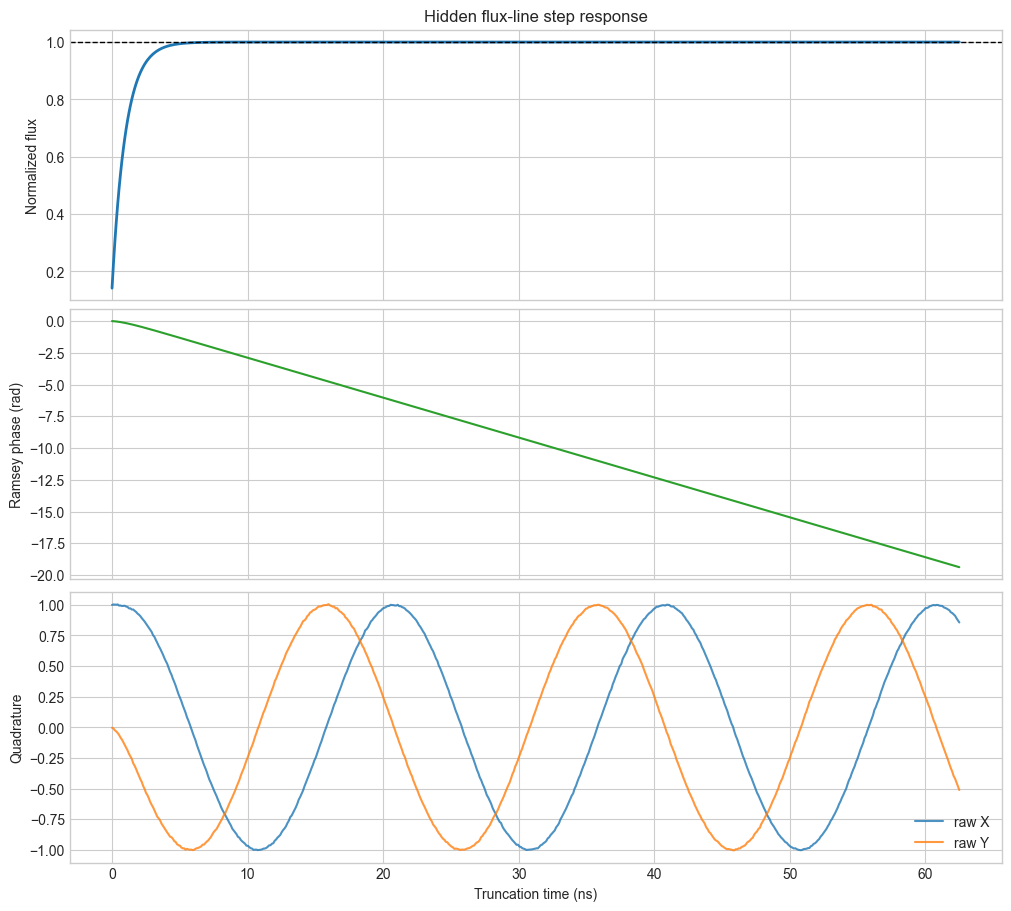

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True, constrained_layout=True)
axes[0].plot(TIME_NS, clean_step_response, linewidth=2)
axes[0].axhline(1, color='black', linestyle='--', linewidth=1)
axes[0].set_ylabel('Normalized flux')
axes[0].set_title('Hidden flux-line step response')
axes[1].plot(TIME_NS, true_phase_rad, color='C2')
axes[1].set_ylabel('Ramsey phase (rad)')
axes[2].plot(TIME_NS, raw_x, label='raw X', alpha=0.8)
axes[2].plot(TIME_NS, raw_y, label='raw Y', alpha=0.8)
axes[2].set_ylabel('Quadrature')
axes[2].set_xlabel('Truncation time (ns)')
axes[2].legend()
plt.show()

## Step 2 — Reconstruct the measured step response

`trace_from_xy` performs `atan2(Y, X)`, phase unwrapping, Savitzky–Golay smoothing, differentiation, and normalization by the steady detuning. In a real experiment, X/Y should first be projected from resonator IQ using ground and excited readout references.


In [4]:
measured_trace = trace_from_xy(
    TIME_NS,
    raw_x,
    raw_y,
    smooth_window=31,
    polyorder=3,
    tail_points=80,
)
measured_step = measured_trace.normalized_step
step_rmse = np.sqrt(np.mean((measured_step - clean_step_response) ** 2))

print(f'Reconstructed steady detuning: {np.median(measured_trace.detuning_mhz[-80:]):.3f} MHz')
print(f'Step-response RMSE: {step_rmse:.5f}')

Reconstructed steady detuning: -50.046 MHz
Step-response RMSE: 0.01034


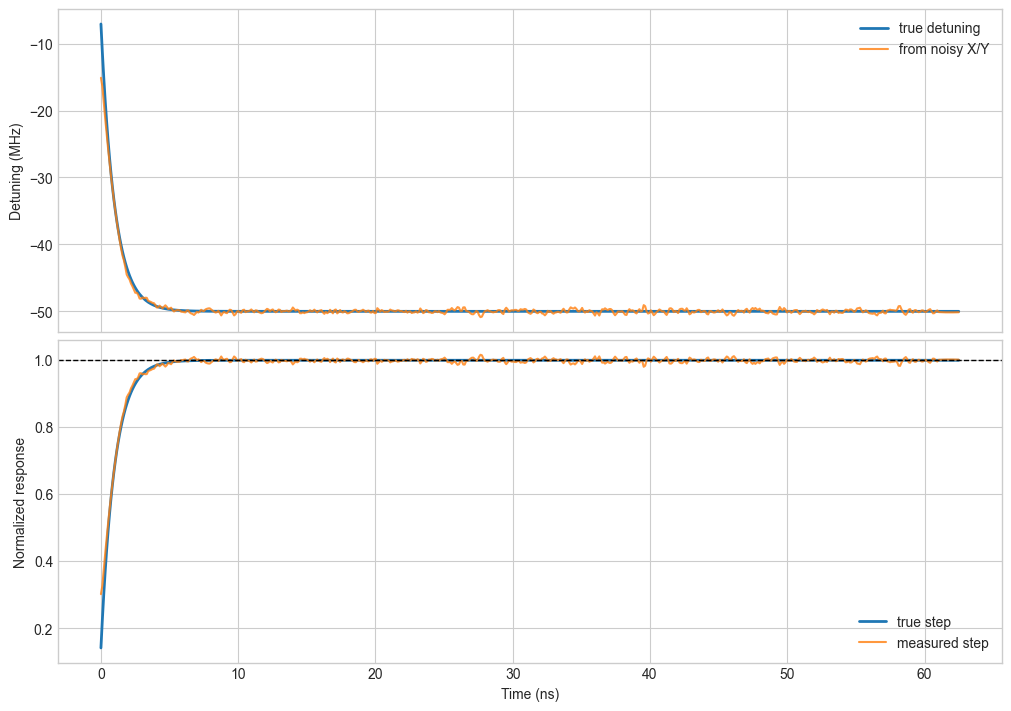

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
axes[0].plot(TIME_NS, true_detuning_mhz, label='true detuning', linewidth=2)
axes[0].plot(TIME_NS, measured_trace.detuning_mhz, label='from noisy X/Y', alpha=0.8)
axes[0].set_ylabel('Detuning (MHz)')
axes[0].legend()
axes[1].plot(TIME_NS, clean_step_response, label='true step', linewidth=2)
axes[1].plot(TIME_NS, measured_step, label='measured step', alpha=0.8)
axes[1].axhline(1, color='black', linestyle='--', linewidth=1)
axes[1].set_ylabel('Normalized response')
axes[1].set_xlabel('Time (ns)')
axes[1].legend()
plt.show()

## Step 3 — Fit a compact IIR line model

The ARX fit estimates the line coefficients from the measured step. The inverse swaps numerator and denominator. This is allowed only when the fitted line is minimum phase; otherwise the inverse poles would be unstable.


In [6]:
inverse_iir = fit_inverse_iir(
    measured_step,
    numerator_order=1,
    denominator_order=1,
    ridge=1e-8,
)
fitted_iir_step = lfilter(
    inverse_iir.line_b, inverse_iir.line_a, np.ones(N_RESPONSE)
)

print('Fitted line b:', inverse_iir.line_b)
print('Fitted line a:', inverse_iir.line_a)
print('Fitted line poles:', inverse_iir.line_poles)
print('Inverse IIR poles:', inverse_iir.inverse_poles)
print('Inverse stable:', np.all(np.abs(inverse_iir.inverse_poles) < 1))

Fitted line b: [ 0.30190066 -0.22187229]
Fitted line a: [ 1.         -0.91997164]
Fitted line poles: [0.91997164]
Inverse IIR poles: [0.73491822]
Inverse stable: True


## Step 4 — Design a regularized causal FIR inverse

The FIR design converts the measured step to an impulse response and solves a regularized convolution problem. A 12-sample delay supplies causal pre-roll. `regularization` limits coefficient magnitude; `smoothness` discourages alternating high-frequency taps.


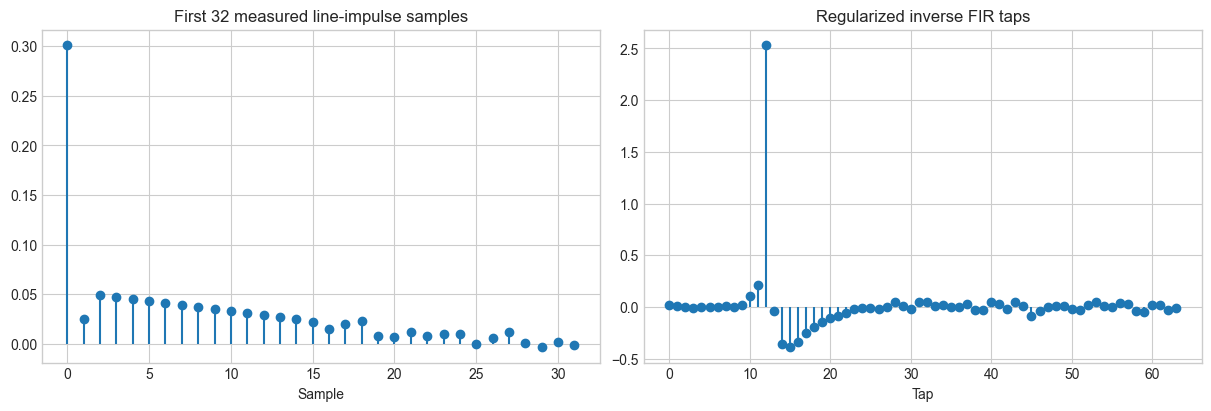

FIR causal delay: 12 samples = 1.252 ns
Peak of line * inverse FIR: 0.7758


In [7]:
inverse_fir = design_inverse_fir(
    measured_step,
    taps=64,
    delay_samples=12,
    regularization=1e-3,
    smoothness=1e-2,
    impulse_samples=300,
)
measured_impulse = impulse_from_step(measured_step)
fir_inverse_check = np.convolve(inverse_fir.line_impulse, inverse_fir.taps)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].stem(np.arange(32), measured_impulse[:32], basefmt=' ')
axes[0].set_title('First 32 measured line-impulse samples')
axes[0].set_xlabel('Sample')
axes[1].stem(np.arange(len(inverse_fir.taps)), inverse_fir.taps, basefmt=' ')
axes[1].set_title('Regularized inverse FIR taps')
axes[1].set_xlabel('Tap')
plt.show()

print(f'FIR causal delay: {inverse_fir.delay_samples} samples = {inverse_fir.delay_samples * DT_NS:.3f} ns')
print(f'Peak of line * inverse FIR: {np.max(np.abs(fir_inverse_check)):.4f}')

## Step 5 — Generate predistorted flux pulses

The desired pulse is a normalized rectangle with amplitude 0.1. A lower amplitude leaves room for inverse-filter overshoot. FIR convolution retains the correction tail; IIR filtering returns one output sample per target sample.


In [8]:
PULSE_AMPLITUDE = 0.10
ACTIVE_SAMPLES = 300
TAIL_SAMPLES = 200
ideal_flux_pulse = np.r_[
    np.full(ACTIVE_SAMPLES, PULSE_AMPLITUDE),
    np.zeros(TAIL_SAMPLES),
]

predistorted_fir_raw = apply_inverse_fir(ideal_flux_pulse, inverse_fir, keep_tail=True)
predistorted_iir_raw = apply_inverse_iir(ideal_flux_pulse, inverse_iir)
predistorted_fir, fir_scale = scale_waveform(predistorted_fir_raw, max_abs=0.95)
predistorted_iir, iir_scale = scale_waveform(predistorted_iir_raw, max_abs=0.95)

print(f'Ideal pulse peak: {np.max(np.abs(ideal_flux_pulse)):.4f}')
print(f'FIR predistortion peak: {np.max(np.abs(predistorted_fir_raw)):.4f}; scale={fir_scale:.4f}')
print(f'IIR predistortion peak: {np.max(np.abs(predistorted_iir_raw)):.4f}; scale={iir_scale:.4f}')

Ideal pulse peak: 0.1000
FIR predistortion peak: 0.2890; scale=1.0000
IIR predistortion peak: 0.3312; scale=1.0000


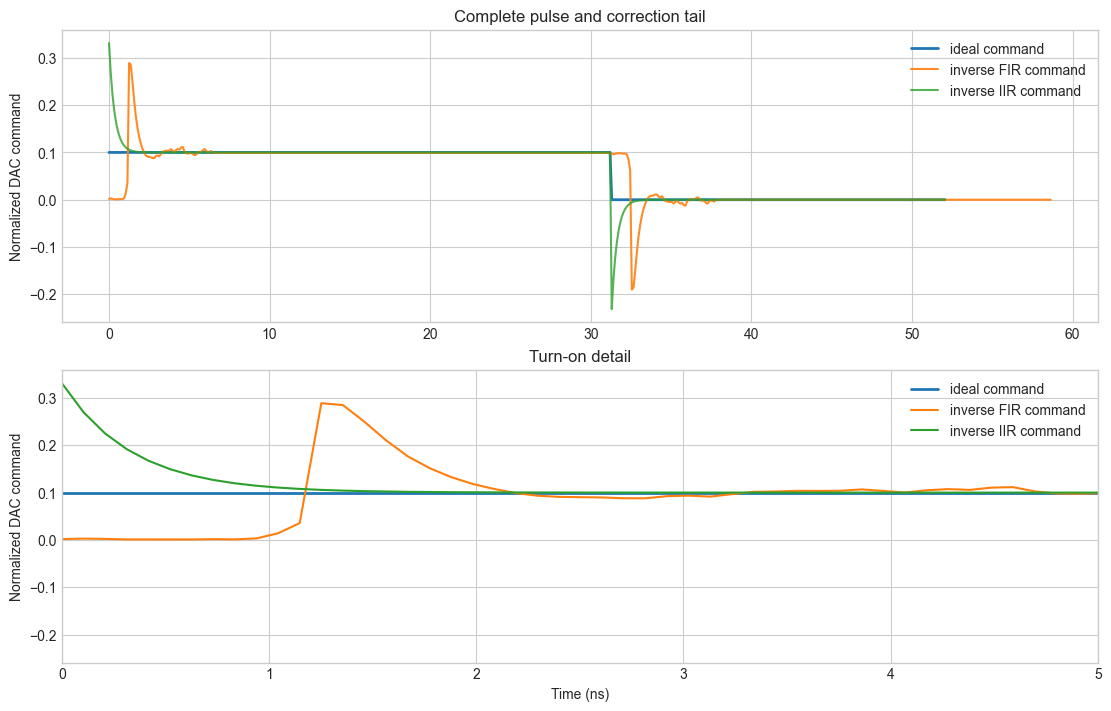

In [9]:
time_ideal_ns = np.arange(len(ideal_flux_pulse)) * DT_NS
time_fir_ns = np.arange(len(predistorted_fir)) * DT_NS
time_iir_ns = np.arange(len(predistorted_iir)) * DT_NS

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False, constrained_layout=True)
axes[0].plot(time_ideal_ns, ideal_flux_pulse, label='ideal command', linewidth=2)
axes[0].plot(time_fir_ns, predistorted_fir, label='inverse FIR command', alpha=0.9)
axes[0].plot(time_iir_ns, predistorted_iir, label='inverse IIR command', alpha=0.8)
axes[0].set_ylabel('Normalized DAC command')
axes[0].set_title('Complete pulse and correction tail')
axes[0].legend()
axes[1].plot(time_ideal_ns, ideal_flux_pulse, label='ideal command', linewidth=2)
axes[1].plot(time_fir_ns, predistorted_fir, label='inverse FIR command')
axes[1].plot(time_iir_ns, predistorted_iir, label='inverse IIR command')
axes[1].set_xlim(0, 5)
axes[1].set_xlabel('Time (ns)')
axes[1].set_ylabel('Normalized DAC command')
axes[1].set_title('Turn-on detail')
axes[1].legend()
plt.show()

## Step 6 — Pass every pulse through the same distorted line

This is the decisive comparison. The uncorrected rectangle, inverse-FIR command, and inverse-IIR command are all sent through the original hidden line model. The FIR output is compared with a target delayed by its intentional 12-sample pre-roll.


In [ ]:
chip_uncorrected = lfilter(true_line_b, true_line_a, ideal_flux_pulse)
chip_fir = lfilter(true_line_b, true_line_a, predistorted_fir)
chip_iir = lfilter(true_line_b, true_line_a, predistorted_iir)

fir_target = np.pad(
    ideal_flux_pulse,
    (inverse_fir.delay_samples, max(0, len(chip_fir) - inverse_fir.delay_samples - len(ideal_flux_pulse))),
)[:len(chip_fir)]
iir_target = ideal_flux_pulse[:len(chip_iir)]

uncorrected_rmse = np.sqrt(np.mean((chip_uncorrected - ideal_flux_pulse) ** 2))
fir_rmse = np.sqrt(np.mean((chip_fir - fir_target) ** 2))
iir_rmse = np.sqrt(np.mean((chip_iir - iir_target) ** 2))

print(f'Uncorrected RMSE: {uncorrected_rmse:.6f}')
print(f'Inverse FIR RMSE: {fir_rmse:.6f}')
print(f'Inverse IIR RMSE: {iir_rmse:.6f}')
print(f'FIR improvement: {uncorrected_rmse / fir_rmse:.2f}x')
print(f'IIR improvement: {uncorrected_rmse / iir_rmse:.2f}x')

Uncorrected RMSE: 0.012511
Inverse FIR RMSE: 0.004137
Inverse IIR RMSE: 0.004508
FIR improvement: 3.02x
IIR improvement: 2.78x


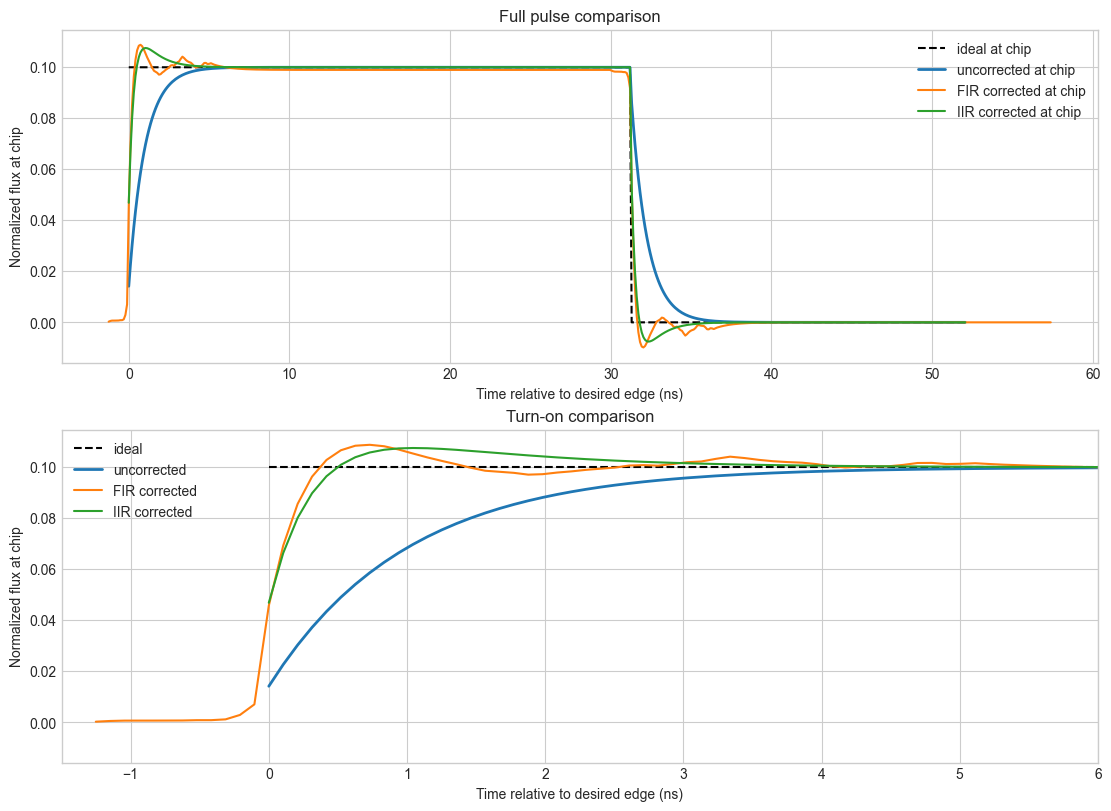

In [ ]:
time_uncorrected_ns = np.arange(len(chip_uncorrected)) * DT_NS
time_fir_aligned_ns = (np.arange(len(chip_fir)) - inverse_fir.delay_samples) * DT_NS
time_iir_output_ns = np.arange(len(chip_iir)) * DT_NS

fig, axes = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True)
axes[0].plot(time_ideal_ns, ideal_flux_pulse, color='black', linestyle='--', label='ideal at chip')
axes[0].plot(time_uncorrected_ns, chip_uncorrected, label='uncorrected at chip', linewidth=2)
axes[0].plot(time_fir_aligned_ns, chip_fir, label='FIR corrected at chip')
axes[0].plot(time_iir_output_ns, chip_iir, label='IIR corrected at chip')
axes[0].set_xlabel('Time relative to desired edge (ns)')
axes[0].set_ylabel('Normalized flux at chip')
axes[0].set_title('Full pulse comparison')
axes[0].legend()
axes[1].plot(time_ideal_ns, ideal_flux_pulse, color='black', linestyle='--', label='ideal')
axes[1].plot(time_uncorrected_ns, chip_uncorrected, label='uncorrected', linewidth=2)
axes[1].plot(time_fir_aligned_ns, chip_fir, label='FIR corrected')
axes[1].plot(time_iir_output_ns, chip_iir, label='IIR corrected')
axes[1].set_xlim(-1.5, 6)
axes[1].set_xlabel('Time relative to desired edge (ns)')
axes[1].set_ylabel('Normalized flux at chip')
axes[1].set_title('Turn-on comparison')
axes[1].legend()
plt.show()

## Checks before hardware

The output below is the normalized array to place in `cfg['predistorted_waveform']`. Before uploading measured-data compensation, always verify: finite samples, peak no larger than one, enough turn-off tail, stable IIR poles, and a second cryoscope measurement after correction.


In [ ]:
# FIR is the conservative default for hardware.
predistorted_waveform = predistorted_fir
assert predistorted_waveform.ndim == 1
assert np.all(np.isfinite(predistorted_waveform))
assert np.max(np.abs(predistorted_waveform)) <= 1.0

hardware_cfg_update = {
    'predistorted_waveform': predistorted_waveform,
    # Keep the same flux_ch, flux_gain, and Gen v6 sample rate used to measure the response.
}

print('Waveform samples ready for QICK:', len(predistorted_waveform))
print('Waveform duration:', len(predistorted_waveform) * DT_NS, 'ns')
print('Waveform peak:', np.max(np.abs(predistorted_waveform)))

Waveform samples ready for QICK: 563
Waveform duration: 58.73981704059829 ns
Waveform peak: 0.28900693591294635


## Next steps

1. Replace `raw_x`, `raw_y`, and `TIME_NS` with calibrated hardware X/Y traces.
2. Keep the FIR regularization strong at first; reduce it only when verification data shows under-correction rather than noise amplification.
3. Treat an unstable IIR inverse as a failed model, not as a coefficient set to upload.
4. Set `corrected_cfg['predistorted_waveform'] = predistorted_waveform`, create `PredistortedCryoscope(corrected_cfg)`, and run `run_xy()` or `run_prefix_sweep()`.
5. Process the corrected X/Y with the same pipeline and compare step flatness and RMSE against the original response.
